In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

df = pd.read_csv('USA_Housing.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

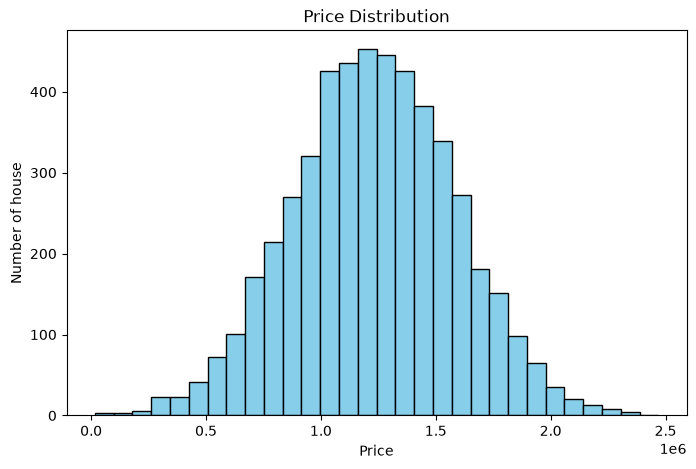

In [2]:
plt.figure(figsize=(8,5))
plt.hist(df['Price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of house')
plt.show()

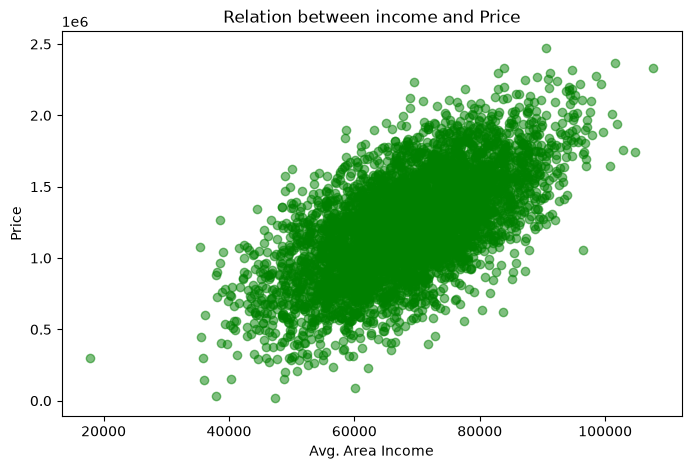

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df['Avg. Area Income'], df['Price'], alpha=0.5, color='green')
plt.title('Relation between income and Price')
plt.xlabel('Avg. Area Income')
plt.ylabel('Price')
plt.show()

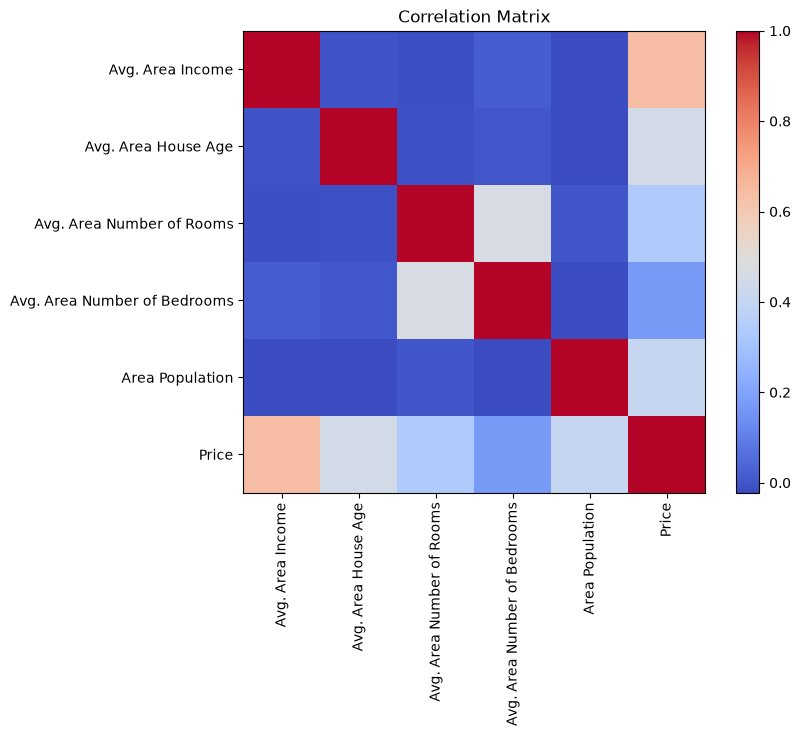

In [4]:
correlation = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Matrix')
plt.show()

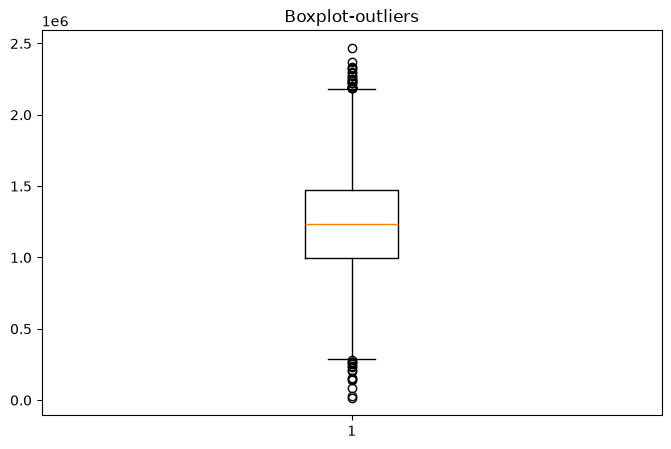

In [5]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Price'])
plt.title('Boxplot-outliers')
plt.show()

In [6]:
df = df.drop('Address', axis=1)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(len(df))
df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]
print(len(df))

5000
4965


In [7]:
X = df.drop('Price', axis=1)
y = df['Price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
for depth in [3, 5, 7, 10, 15]:
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_model.fit(X_train_scaled, y_train)
    dt_pred = dt_model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, dt_pred)
    rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
    
    print(f"max_depth={depth} -> R²: {r2:.4f}, RMSE: {rmse:.2f}")

max_depth=3 -> R²: 0.5036, RMSE: 233169.15
max_depth=5 -> R²: 0.6374, RMSE: 199280.05
max_depth=7 -> R²: 0.7213, RMSE: 174720.37
max_depth=10 -> R²: 0.7604, RMSE: 162000.39
max_depth=15 -> R²: 0.7305, RMSE: 171820.07


In [11]:
results = {}


lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

results['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test, lr_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_pred)),
    'R2': r2_score(y_test, lr_pred)
}

dt_model = DecisionTreeRegressor(max_depth=10,random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

results['Decision Tree'] = {
    'MAE': mean_absolute_error(y_test, dt_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, dt_pred)),
    'R2': r2_score(y_test, dt_pred)
}


rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

results['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'R2': r2_score(y_test, rf_pred)
}

results_df = pd.DataFrame(results).T
print(results_df)

                             MAE           RMSE        R2
Linear Regression   81132.082306  101261.884569  0.906385
Decision Tree      129480.459659  162000.385716  0.760401
Random Forest       94358.675055  117719.192233  0.873483


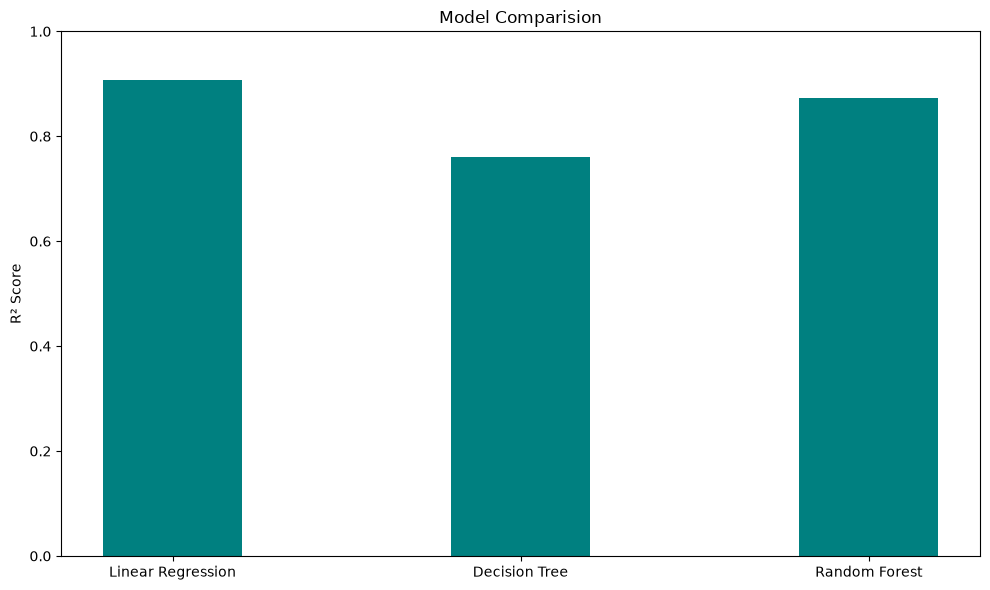

In [12]:
import matplotlib.pyplot as plt
import numpy as np

models = results_df.index 
x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots(figsize=(10,6))

bars = ax1.bar(x, results_df['R2'], width=0.4, color='teal', label='R² Score')
ax1.set_ylabel('R² Score')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_title('Model Comparision')

plt.tight_layout()
plt.show()

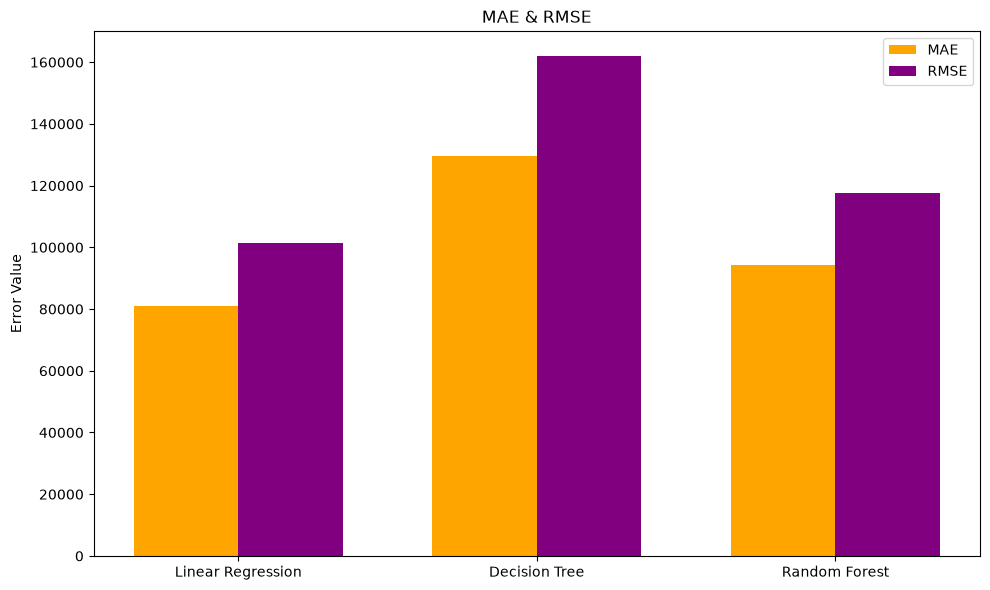

In [13]:
fig, ax2 = plt.subplots(figsize=(10,6))

width = 0.35
ax2.bar(x - width/2, results_df['MAE'], width, label='MAE', color='orange')
ax2.bar(x + width/2, results_df['RMSE'], width, label='RMSE', color='purple')

ax2.set_ylabel('Error Value')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.set_title('MAE & RMSE')
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
import joblib

joblib.dump(lr_model, 'house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')






['scaler.pkl']

In [15]:
loaded_model = joblib.load('house_price_model.pkl')
scaler = joblib.load('scaler.pkl')


In [16]:
new_house = pd.DataFrame({
    'Avg. Area Income': [65000],
    'Avg. Area House Age': [6],
    'Avg. Area Number of Rooms': [7],
    'Avg. Area Number of Bedrooms': [4],
    'Area Population': [35000]
})
scaler.transform(new_house)
new_house_scaled = scaler.transform(new_house)
prediction = loaded_model.predict(new_house_scaled)[0]

print("Entered new house:")
display(new_house)


for feature,value in new_house.iloc[0].items():
    print(f"{feature}: {value}")

print(f"Predicted House Price: ${prediction:,.2f}")


Entered new house:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,65000,6,7,4,35000


Avg. Area Income: 65000
Avg. Area House Age: 6
Avg. Area Number of Rooms: 7
Avg. Area Number of Bedrooms: 4
Area Population: 35000
Predicted House Price: $1,142,334.80


In [17]:
from IPython.display import display, clear_output
import ipywidgets as widgets
AvgIncome_widget = widgets.IntSlider(
    value=45000,
    min=0,
    max=400000,
    step=1000,
    description="Area income:",
    style={"description_width": "initial"},
    continuous_update=False
)
AvgHouseAge_widget = widgets.IntSlider(
    value=6.,
    min=0.,
    max=30,
    step=1,
    description="House Age:",
    style={"description_width": "initial"},
    continuous_update=False
)
NumberOfRooms_widget= widgets.IntSlider(
    value=5,
    min=0,
    max=15,
    step=1,
    description="Number of rooms:",
    style={"description_width": "initial"},
    continuous_update=False
)
NumberOfedrooms_widget= widgets.IntSlider(
    value=3,
    min=0,
    max=9,
    step=1,
    description="Number of bedrooms:",
    style={"description_width": "initial"},
    continuous_update=False
)
AreaPopulation_widget= widgets.IntSlider(
    value=30000,
    min=0,
    max=250000,
    step=1000,
    description="Area population:",
    style={"description_width": "initial"},
    continuous_update=False
)
predict_button = widgets.Button(
    description="Predict house price",
    button_style="success",
    icon="check"
)
output_area = widgets.Output()




In [18]:
def predict_House_price(button):
    with output_area:
        clear_output()

        new_house = pd.DataFrame({
            "Avg. Area Income": [
                AvgIncome_widget.value
            ],
            "Avg. Area House Age": [
             AvgHouseAge_widget.value
            ],
            "Avg. Area Number of Rooms": [
                NumberOfRooms_widget.value
            ],
            "Avg. Area Number of Bedrooms": [
              NumberOfedrooms_widget.value
            ],

            "Area Population": [
                AreaPopulation_widget.value
            ]
        })
        new_house_scaled = scaler.transform(new_house)
        prediction = loaded_model.predict(
            new_house_scaled
        )[0]
        print("=" * 50)
        print("HOUSE PRICE PREDICTION")
        print("=" * 50)

        print("\nEntered House Data:")

        display(new_house)

        print("\nPredicted House Price:")

        print(
            f"${prediction:,.2f}"
        )
   





In [19]:
predict_button.on_click(
    predict_House_price
)
display(
    AvgIncome_widget,
    AvgHouseAge_widget ,
    NumberOfRooms_widget,
    NumberOfedrooms_widget,
    AreaPopulation_widget,
    predict_button,
    output_area
)

IntSlider(value=45000, continuous_update=False, description='Area income:', max=400000, step=1000, style=Slide…

IntSlider(value=6, continuous_update=False, description='House Age:', max=30, style=SliderStyle(description_wi…

IntSlider(value=5, continuous_update=False, description='Number of rooms:', max=15, style=SliderStyle(descript…

IntSlider(value=3, continuous_update=False, description='Number of bedrooms:', max=9, style=SliderStyle(descri…

IntSlider(value=30000, continuous_update=False, description='Area population:', max=250000, step=1000, style=S…

Button(button_style='success', description='Predict house price', icon='check', style=ButtonStyle())

Output()